# **Industrial Machine Failure Model**

In [192]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [193]:
df = pd.read_csv('simulated_iiot_dataset.csv')

In [194]:
df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure,timestamp
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0,1/1/2024 0:00
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0,1/1/2024 1:00
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0,1/1/2024 2:00
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0,1/1/2024 3:00
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1,1/1/2024 4:00


In [195]:
df['machine_failure'].unique()

array([0, 1])

In [196]:
df.shape

(1000, 17)

In [197]:
df.columns

Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure', 'timestamp'],
      dtype='object')

In [198]:
df.isnull().sum()

temperature            0
vibration              0
pressure               0
humidity               0
rotation_speed         0
voltage                0
current                0
oil_level              0
load                   0
motor_temperature      0
gearbox_temperature    0
sound_level            0
fan_speed              0
reactive_power         0
active_power           0
machine_failure        0
timestamp              0
dtype: int64

In [199]:
df.value_counts().sum()

1000

In [200]:
df.describe()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.096660,0.507084,30.017503,39.906404,1497.536318,219.532624,4.985922,70.096085,80.183418,59.939829,64.800457,74.966418,1200.436575,50.319840,100.311680,0.162000
std,4.896080,0.099745,2.950363,5.135663,49.619011,10.073892,0.512502,5.208700,10.116854,4.825616,4.852018,3.044218,48.661286,5.127844,10.074989,0.368635
min,58.793663,0.205961,20.941464,25.352757,1341.164809,191.004861,3.643694,51.558174,41.633445,40.387999,48.837173,64.873263,1060.851978,34.587189,66.704962,0.000000
25%,71.762048,0.439376,28.056001,36.312898,1465.869752,213.063072,4.622431,66.539219,73.631455,56.783329,61.565503,73.026418,1167.578101,46.849870,93.355223,0.000000
50%,75.126503,0.506308,29.999248,40.000923,1499.087900,219.571729,4.972627,70.024899,80.191240,60.021831,64.718429,74.903191,1200.553492,50.402801,100.112341,0.000000
75%,78.239719,0.572888,31.982746,43.334727,1531.956157,226.124468,5.349873,73.617006,86.772041,63.253711,68.061675,76.904721,1233.210037,53.686347,107.190268,0.000000
max,94.263657,0.819311,41.778713,56.215465,1655.645510,250.982994,6.764528,85.588406,113.773829,73.841868,79.570546,85.133305,1364.205910,67.144552,131.404229,1.000000


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='machine_failure', ylabel='Count'>

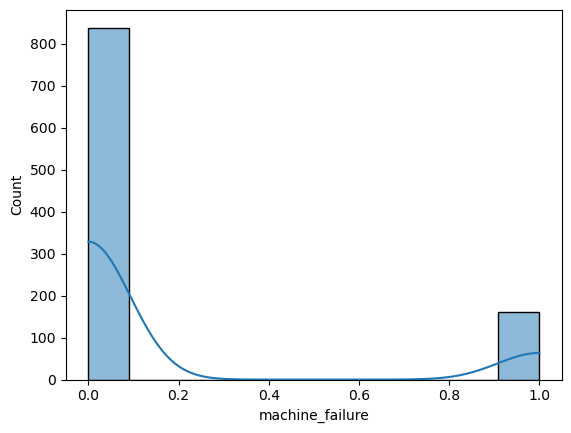

In [201]:
sns.histplot(df['machine_failure'], kde = True)

In [202]:
df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure,timestamp
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0,1/1/2024 0:00
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0,1/1/2024 1:00
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0,1/1/2024 2:00
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0,1/1/2024 3:00
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1,1/1/2024 4:00


<Axes: >

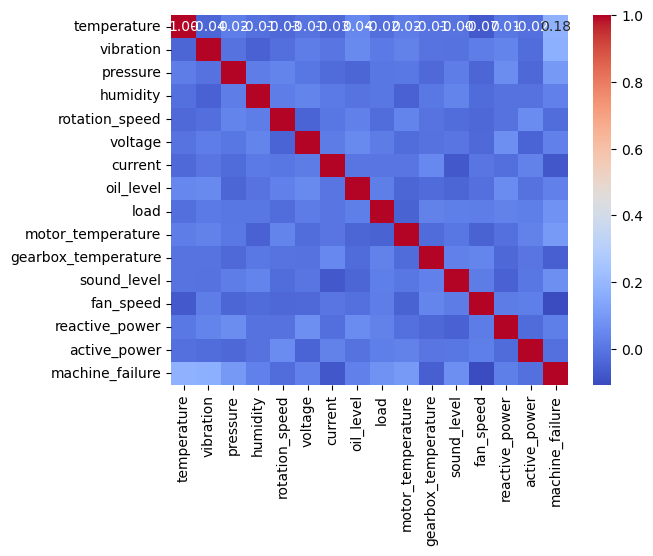

In [203]:
sns.heatmap(df.corr(numeric_only =True), annot=True, cmap="coolwarm", fmt=".2f")

In [204]:
df = df.drop('timestamp' , axis =1)

In [205]:
df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1


In [206]:
num_features = df.select_dtypes(include='number')
num_features

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,73.594499,0.607015,30.232442,40.142288,1497.551748,221.714693,4.851067,81.049278,81.016301,66.505510,66.207046,71.456419,1172.785585,53.091447,90.903480,1
996,83.988433,0.497348,30.773258,29.610941,1535.570529,231.526481,5.384516,71.634973,91.672177,50.008275,66.626258,74.781533,1196.094549,52.083295,112.371510,0
997,78.204214,0.411813,26.274718,38.398511,1655.645510,207.825962,4.736305,65.824377,95.884472,56.473416,70.896316,77.514042,1173.631833,48.072205,113.122080,0
998,72.144105,0.483693,31.002529,48.216891,1540.401809,224.679504,4.997447,78.264565,73.150128,62.478828,68.955700,74.697912,1277.144405,50.954619,91.158909,0


In [207]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 -1.5 *IQR
upper_bound = Q3 +1.5 *IQR

In [208]:
outliers = (num_features<lower_bound) | (num_features> upper_bound)


In [209]:
df.drop_duplicates()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,73.594499,0.607015,30.232442,40.142288,1497.551748,221.714693,4.851067,81.049278,81.016301,66.505510,66.207046,71.456419,1172.785585,53.091447,90.903480,1
996,83.988433,0.497348,30.773258,29.610941,1535.570529,231.526481,5.384516,71.634973,91.672177,50.008275,66.626258,74.781533,1196.094549,52.083295,112.371510,0
997,78.204214,0.411813,26.274718,38.398511,1655.645510,207.825962,4.736305,65.824377,95.884472,56.473416,70.896316,77.514042,1173.631833,48.072205,113.122080,0
998,72.144105,0.483693,31.002529,48.216891,1540.401809,224.679504,4.997447,78.264565,73.150128,62.478828,68.955700,74.697912,1277.144405,50.954619,91.158909,0


In [210]:
df.describe()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.096660,0.507084,30.017503,39.906404,1497.536318,219.532624,4.985922,70.096085,80.183418,59.939829,64.800457,74.966418,1200.436575,50.319840,100.311680,0.162000
std,4.896080,0.099745,2.950363,5.135663,49.619011,10.073892,0.512502,5.208700,10.116854,4.825616,4.852018,3.044218,48.661286,5.127844,10.074989,0.368635
min,58.793663,0.205961,20.941464,25.352757,1341.164809,191.004861,3.643694,51.558174,41.633445,40.387999,48.837173,64.873263,1060.851978,34.587189,66.704962,0.000000
25%,71.762048,0.439376,28.056001,36.312898,1465.869752,213.063072,4.622431,66.539219,73.631455,56.783329,61.565503,73.026418,1167.578101,46.849870,93.355223,0.000000
50%,75.126503,0.506308,29.999248,40.000923,1499.087900,219.571729,4.972627,70.024899,80.191240,60.021831,64.718429,74.903191,1200.553492,50.402801,100.112341,0.000000
75%,78.239719,0.572888,31.982746,43.334727,1531.956157,226.124468,5.349873,73.617006,86.772041,63.253711,68.061675,76.904721,1233.210037,53.686347,107.190268,0.000000
max,94.263657,0.819311,41.778713,56.215465,1655.645510,250.982994,6.764528,85.588406,113.773829,73.841868,79.570546,85.133305,1364.205910,67.144552,131.404229,1.000000


In [211]:
df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1


In [212]:
num_cols = df.select_dtypes(include = 'number')
num_cols .skew()

temperature            0.116976
vibration             -0.049396
pressure               0.061247
humidity              -0.002121
rotation_speed        -0.175801
voltage                0.100813
current                0.118649
oil_level             -0.025587
load                  -0.024400
motor_temperature     -0.110978
gearbox_temperature   -0.031314
sound_level           -0.049134
fan_speed              0.018262
reactive_power         0.026227
active_power          -0.023452
machine_failure        1.837466
dtype: float64

In [213]:
df.columns

Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure'],
      dtype='object')

In [214]:
from sklearn.model_selection import train_test_split
numeric_cols = ['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power']
X = df[numeric_cols]
y = df['machine_failure']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42)



In [215]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
numeric_pipeline = Pipeline(steps =[
    ('scale' , StandardScaler())
])

In [216]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("Numeric_cols", numeric_pipeline , numeric_cols)
])

In [217]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score ,r2_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor' , preprocessor),
    ("LogisticRegression" ,LogisticRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

print(f"Accuracy of Training {accuracy_score(y_train,lr_preds_train)}")
print(f"Accuracy of Testing {accuracy_score(y_test,lr_preds)}")



Accuracy of Training 0.84375
Accuracy of Testing 0.825


In [218]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("random_forest", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline.fit(X_train,y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

print(f"Accuracy of Training {accuracy_score(y_train,rf_preds_train)}")
print(f"Accuracy of Testing {accuracy_score(y_test,rf_preds)}")

Accuracy of Training 0.995
Accuracy of Testing 0.805


In [219]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

rf_predictions = rf_pipeline.predict(X_test)

print("Predicted classes:")
print(pd.Series(rf_predictions).value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Predicted classes:
0    173
1     27
Name: count, dtype: int64

Confusion Matrix:
[[151  17]
 [ 22  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       168
           1       0.37      0.31      0.34        32

    accuracy                           0.81       200
   macro avg       0.62      0.61      0.61       200
weighted avg       0.79      0.81      0.80       200



In [220]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc' , SVC( class_weight="balanced",
        random_state=42))
])

svc_pipeline.fit(X_train,y_train)
svc_preds = svc_pipeline.predict(X_test)
svc_preds_train = svc_pipeline.predict(X_train)
print(f"Accuracy of Training {accuracy_score(y_train,svc_preds_train)}")
print(f"Accuracy of Testing {accuracy_score(y_test,svc_preds)}")

Accuracy of Training 0.88375
Accuracy of Testing 0.715


In [221]:
from sklearn.ensemble import GradientBoostingClassifier
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_train_pred = gb_pipeline.predict(X_train)
gb_test_pred = gb_pipeline.predict(X_test)

gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_test_acc = accuracy_score(y_test, gb_test_pred)
print (f"The training accuracy is : {gb_train_acc}")
print (f"The testing accuracy is : {gb_test_acc}")

The training accuracy is : 1.0
The testing accuracy is : 0.855


In [222]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__gamma": ["scale", "auto"],
    "svc__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=svc_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svc__C': [0.1, 1, ...], 'svc__class_weight': [None, 'balanced'], 'svc__gamma': ['scale', 'auto'], 'svc__kernel': ['linear', 'rbf', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function w

In [223]:
random_search.best_params_

{'svc__kernel': 'linear',
 'svc__gamma': 'auto',
 'svc__class_weight': None,
 'svc__C': 10}

In [224]:
svc_best_pipeline = random_search.best_estimator_
svc_best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['temperature','vibration','pressure',...,'fan_speed','reactive_power', 'active_power']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numeric_cols', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [225]:
svc_best_preds = svc_best_pipeline.predict(X_test)
print(f"The accurac_yscore of the SVM after hyperparameter tuning is: {accuracy_score (y_test, svc_best_preds)}")

The accurac_yscore of the SVM after hyperparameter tuning is: 0.84


In [227]:
import joblib
joblib.dump(svc_pipeline,'Industrial_Machine Failure Prediction.pkl')

['Industrial_Machine Failure Prediction.pkl']